# Simulation notebook




In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.special import expit, logit
from scipy.optimize import fsolve
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True


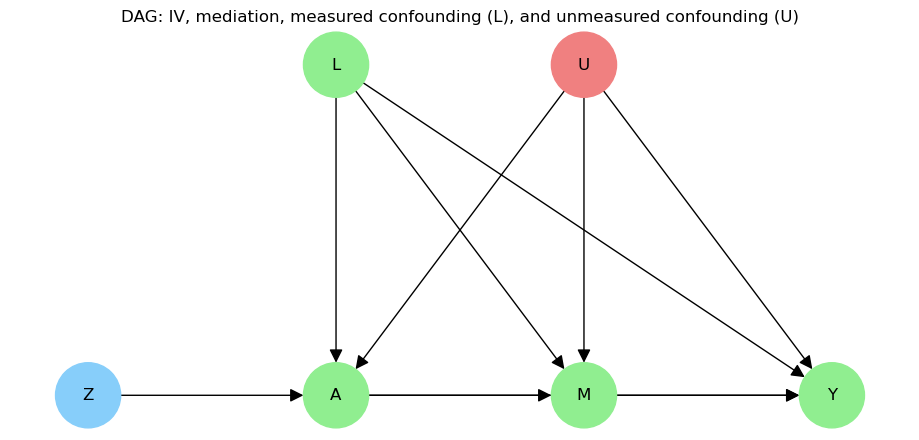

In [24]:
def draw_dag():
    G = nx.DiGraph()
    edges = [
        ("Z", "A"),
        ("L", "A"), ("L", "M"), ("L", "Y"),
        ("U", "A"), ("U", "M"), ("U", "Y"),
        ("A", "M"), ("A", "Y"),
        ("M", "Y")
    ]
    G.add_edges_from(edges)

    pos = {
        "Z": (0.0, 1.0),
        "A": (2.0, 1.0),
        "L": (2.0, 2.0),
        "U": (4.0, 2.0),
        "M": (4.0, 1.0),
        "Y": (6.0, 1.0),
    }

    node_colors = []
    for node in G.nodes():
        if node == "Z":
            node_colors.append("lightskyblue")
        elif node == "U":
            node_colors.append("lightcoral")
        else:
            node_colors.append("lightgreen")

    plt.figure(figsize=(9, 4))
    nx.draw(
        G, pos, with_labels=True, node_color=node_colors,
        node_size=2200, arrowsize=20, font_size=12
    )
    plt.title("DAG: IV, mediation, measured confounding (L), and unmeasured confounding (U)")
    plt.show()

draw_dag()


## Data-generating mechanism

`with_u=True` creates unmeasured confounding through `U`.<br>
`with_u=False` removes the effect of `U`, **but** measured confounding through `L` remains.<br>
Therefore, the naive estimator below is adjusted for `L` rather than being a crude unadjusted difference.


In [25]:
def simulate_data(N=5000, with_u=True, seed=None):
    rng = np.random.default_rng(seed)

    Z = rng.binomial(1, 0.5, N)
    U = rng.normal(0, 1, N)
    L = rng.normal(0.5, 0.5, N)

    u_coeff_a = 0.8 if with_u else 0.0
    u_coeff_m = 0.7 if with_u else 0.0
    u_coeff_y = 1.2 if with_u else 0.0

    pA = expit(-1.0 + 1.5 * Z + 0.5 * L + u_coeff_a * U)
    A = rng.binomial(1, pA)

    pM = expit(-2.0 + 2.0 * A + 0.5 * L + u_coeff_m * U)
    M = rng.binomial(1, pM)

    pY = expit(-3.0 + 1.0 * A + 1.5 * M - 1.0 * L + u_coeff_y * U)
    Y = rng.binomial(1, pY)

    return pd.DataFrame({"Z": Z, "A": A, "M": M, "Y": Y, "L": L, "U": U})


def safe_nnt_from_risk_difference(rd, eps=1e-8):
    if np.abs(rd) < eps:
        return np.nan
    return 1.0 / rd


In [26]:
def true_nnt_mc(df, with_u=True):
    L = df["L"].to_numpy()
    U = df["U"].to_numpy()

    u_coeff_m = 0.7 if with_u else 0.0
    u_coeff_y = 1.2 if with_u else 0.0

    pM1 = expit(-2.0 + 2.0 * 1 + 0.5 * L + u_coeff_m * U)
    pM0 = expit(-2.0 + 2.0 * 0 + 0.5 * L + u_coeff_m * U)

    pY_11 = expit(-3.0 + 1.0 * 1 + 1.5 * 1 - 1.0 * L + u_coeff_y * U)
    pY_10 = expit(-3.0 + 1.0 * 1 + 1.5 * 0 - 1.0 * L + u_coeff_y * U)
    pY_01 = expit(-3.0 + 1.0 * 0 + 1.5 * 1 - 1.0 * L + u_coeff_y * U)
    pY_00 = expit(-3.0 + 1.0 * 0 + 1.5 * 0 - 1.0 * L + u_coeff_y * U)

    EY1 = np.mean(pY_11 * pM1 + pY_10 * (1 - pM1))
    EY0 = np.mean(pY_01 * pM0 + pY_00 * (1 - pM0))

    return safe_nnt_from_risk_difference(EY1 - EY0)


def naive_adjusted_nnt(df):
    X = sm.add_constant(df[["A", "L"]], has_constant="add")
    fit = sm.Logit(df["Y"], X).fit(disp=0)

    X1 = X.copy()
    X1["A"] = 1
    X0 = X.copy()
    X0["A"] = 0

    p1 = fit.predict(X1).mean()
    p0 = fit.predict(X0).mean()

    return safe_nnt_from_risk_difference(p1 - p0)


def crude_unadjusted_nnt(df):
    p1 = df.loc[df["A"] == 1, "Y"].mean()
    p0 = df.loc[df["A"] == 0, "Y"].mean()
    return safe_nnt_from_risk_difference(p1 - p0)


In [27]:
def g_estimation_nnt(df):
    Z = df["Z"].values
    A = df["A"].values
    Y = df["Y"].values

    X_model = sm.add_constant(df[["A", "Z", "L"]], has_constant="add")
    fit = sm.Logit(Y, X_model).fit(disp=0)

    beta = fit.params.values
    X_np = X_model.values

    def estimating_equation(psi):
        pred_logit = X_np @ beta
        pz = np.mean(Z)
        h_psi = expit(pred_logit - A * psi)
        return np.sum((Z - pz) * h_psi)

    psi_hat = float(fsolve(estimating_equation, x0=0.0)[0])

    linear_predictor = X_np @ beta

    y0_pot = expit(linear_predictor - A * psi_hat)
    y1_pot = expit(linear_predictor + (1 - A) * psi_hat)

    rd = np.mean(y1_pot) - np.mean(y0_pot)
    nnt = np.inf if np.isclose(rd, 0) else 1 / rd

    return nnt, psi_hat

In [28]:
def run_many_simulations(n_rep=100, N=5000, with_u=True, base_seed=12345):
    rows = []

    for r in range(n_rep):
        df = simulate_data(N=N, with_u=with_u, seed=base_seed + r)

        true_nnt = true_nnt_mc(df, with_u=with_u)
        naive_nnt = naive_adjusted_nnt(df)
        g_nnt, psi_hat = g_estimation_nnt(df)
        crude_nnt = crude_unadjusted_nnt(df)

        rows.append({
            "scenario": "With U" if with_u else "Without U",
            "rep": r + 1,
            "true_nnt": true_nnt,
            "naive_nnt": naive_nnt,
            "g_nnt": g_nnt,
            "crude_unadjusted_nnt": crude_nnt,
            "psi_hat": psi_hat
        })

    return pd.DataFrame(rows)


results_with_u = run_many_simulations(n_rep=100, N=5000, with_u=True, base_seed=1000)
results_without_u = run_many_simulations(n_rep=100, N=5000, with_u=False, base_seed=5000)

results = pd.concat([results_with_u, results_without_u], ignore_index=True)
results.head()


,scenario,rep,true_nnt,naive_nnt,g_nnt,crude_unadjusted_nnt,psi_hat
0,With U,1,6.295577,4.011633,5.952896,4.190044,1.433759
1,With U,2,6.226971,3.744164,5.579052,3.851368,1.482524
2,With U,3,6.193852,3.929433,4.842416,4.081415,1.722420
3,With U,4,6.268816,3.771060,6.951181,3.909086,1.165111
4,With U,5,6.231490,4.050447,5.934138,4.187048,1.472837


In [29]:
summary = (
    results.groupby("scenario")[["true_nnt", "naive_nnt", "g_nnt", "crude_unadjusted_nnt"]]
    .agg(["mean", "std"])
    .round(3)
)
summary


true_nnt        naive_nnt         g_nnt        crude_unadjusted_nnt  \
              mean    std      mean    std   mean    std                 mean   
scenario                                                                        
With U       6.215  0.062     4.028  0.177  6.594  1.421                4.184   
Without U    6.954  0.027     7.019  0.410  7.028  1.342                7.450   

                  
             std  
scenario          
With U     0.192  
Without U  0.477

## Main plot

Each scenario includes:
- true parameter
- naive estimator
- G-estimator

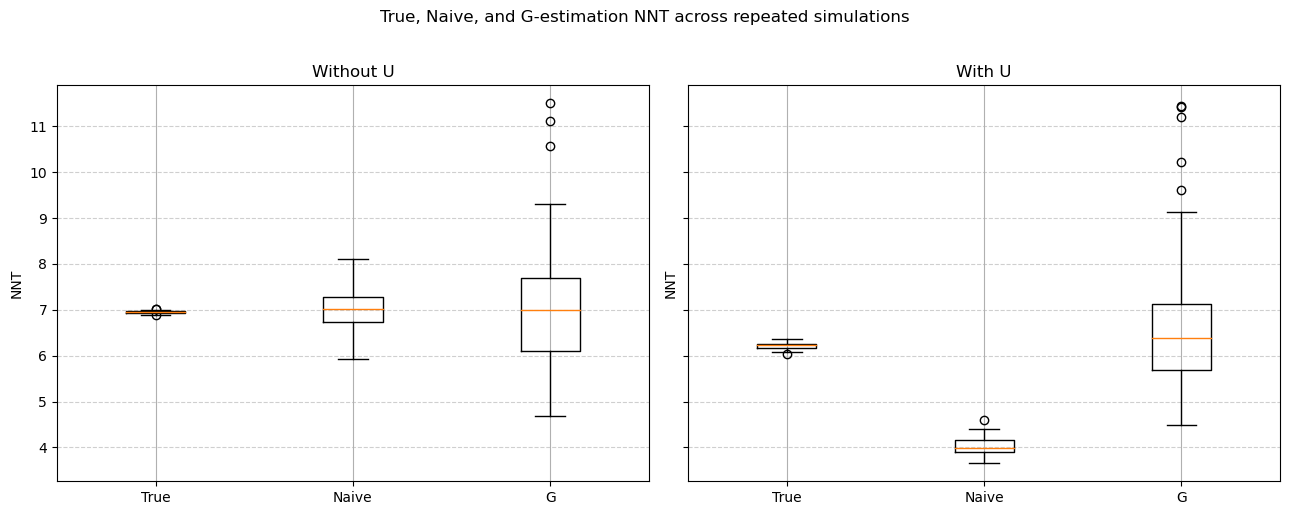

In [30]:
plot_df = results.melt(
    id_vars=["scenario", "rep"],
    value_vars=["true_nnt", "naive_nnt", "g_nnt"],
    var_name="estimator",
    value_name="nnt"
)

estimator_order = ["true_nnt", "naive_nnt", "g_nnt"]
scenario_order = ["Without U", "With U"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, scenario in zip(axes, scenario_order):
    subset = plot_df[plot_df["scenario"] == scenario]
    data = [subset.loc[subset["estimator"] == est, "nnt"].dropna().values for est in estimator_order]

    ax.boxplot(data, labels=["True", "Naive", "G"], patch_artist=False)
    ax.set_title(scenario)
    ax.set_ylabel("NNT")
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.suptitle("True, Naive, and G-estimation NNT across repeated simulations", y=1.02)
plt.tight_layout()
plt.show()


# Short interpretation

- `Without U:` the adjusted naive estimator is close to the true NNT, as expected when there is no unmeasured confounding.<br>
- `With U:` the naive estimator becomes clearly biased and moves away from the true NNT.<br>
- In contrast, the G-estimator remains closer to the true NNT under unmeasured confounding, although it shows greater variability across simulations.<br>
- The crude unadjusted estimator is presented only as a diagnostic benchmark, since it may remain biased whenever measured confounders such as L affect both A and Y.<br>